In [1]:
import torch
from torch import nn
from torch import pca_lowrank
from torch import functional as F

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.datasets import TUDataset, MoleculeNet

from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

from tqdm import tqdm

from sklearn.metrics import roc_auc_score

from typing import Optional

d:\College 2\sem 4\graph-aggregration\graph-pooling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Exploring the library and loading data

In [2]:
edge_index = torch.tensor([
    [0, 1],
    [1, 2],
    [1, 0],
    [2, 1]
], dtype=torch.long)

x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index.T.contiguous())

In [3]:
# dataset = TUDataset(root='../datasets/FRANKENSTEIN', name='FRANKENSTEIN').shuffle()
dataset = MoleculeNet(root='../datasets/BACE', name='BACE').shuffle()

In [4]:
print(dataset)
print(dataset.num_classes)
# print(dataset.num_edge_attributes)
print(dataset.num_node_features)
print(len(dataset))

BACE(1513)
2
9
1513


In [5]:
dataset.y.unique(return_counts=True)

(tensor([0., 1.]), tensor([822, 691]))

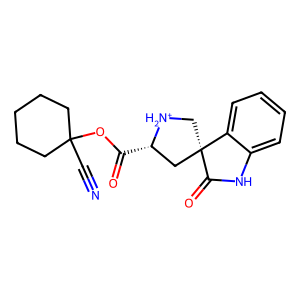

In [6]:
smiles_strn = dataset[10].smiles
mol = Chem.MolFromSmiles(smiles_strn)
Draw.MolToImage(mol)

In [7]:
len(dataset)

1513

In [8]:
dataset.x.shape

torch.Size([51577, 9])

# Training a simple GCN

In [9]:
train_set = dataset[:int(len(dataset)*0.8)]
test_set = dataset[int(len(dataset)*0.8):]
print(train_set)
print(test_set)

BACE(1210)
BACE(303)


In [10]:
train_loader = DataLoader(train_set, batch_size=64)
test_loader = DataLoader(test_set, batch_size=64)

In [11]:
all_loader = DataLoader(dataset, batch_size=64)

In [12]:
class GCN(nn.Module):
    def __init__(self, device='cpu'):
        super().__init__()
        self.device = device

        self.conv1 = GCNConv(dataset.num_node_features, 128)
        self.act = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.conv2 = GCNConv(128, 128)
        self.agg = global_mean_pool

        self.head1 = nn.Linear(128, 64)
        self.head2 = nn.Linear(64, 1)

        self.act2 = nn.Sigmoid()
        
        self.to(device)

    def forward(self, data):
        x = data.x.to(self.device)
        edge_index = data.edge_index.to(self.device)
        batch = data.batch.to(self.device)

        x = x.float()
        x = self.conv1(x, edge_index)
        x = self.act(x)

        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.act(x)

        x = self.dropout(x)
        
        x = self.agg(x, batch)
        
        x = self.head1(x)
        x = self.act(x)
        x = self.head2(x)
        return x# self.act2(x)





In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = 'cpu'
model = GCN(device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

In [14]:
for train_batch in train_loader:
    break
model(train_batch)

tensor([[ 0.0027],
        [ 0.0077],
        [-0.0319],
        [ 0.0074],
        [-0.0364],
        [-0.0157],
        [ 0.0078],
        [-0.0443],
        [-0.0740],
        [-0.0311],
        [ 0.0116],
        [ 0.0181],
        [-0.0276],
        [-0.0395],
        [ 0.0373],
        [-0.0376],
        [ 0.0094],
        [ 0.0026],
        [ 0.0384],
        [-0.0003],
        [-0.0618],
        [-0.0417],
        [ 0.0466],
        [ 0.0083],
        [ 0.0176],
        [ 0.0221],
        [-0.0294],
        [-0.0218],
        [ 0.0206],
        [ 0.0235],
        [-0.0061],
        [-0.0475],
        [ 0.0030],
        [-0.0038],
        [ 0.0282],
        [-0.0180],
        [-0.0595],
        [-0.0095],
        [-0.0390],
        [-0.0241],
        [-0.0279],
        [-0.0705],
        [ 0.0508],
        [ 0.0270],
        [-0.0299],
        [-0.0557],
        [-0.0017],
        [ 0.0162],
        [-0.0055],
        [-0.0072],
        [ 0.0091],
        [ 0.0029],
        [-0.

In [15]:
model.train()
for epoch in (pbar := tqdm(range(1000))):
    total_loss = 0
    for train_batch in train_loader:
        optimizer.zero_grad()

        out = model(train_batch)
        loss = loss_fn(out, train_batch.y.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    pbar.set_description(f'Loss: {total_loss/len(train_loader):.4f}')
    
    # if (epoch + 1) % 50 == 0:
    #     print(f'Epoch {epoch}:', total_loss/len(all_loader))
    
        

Loss: 0.4031: 100%|██████████| 1000/1000 [01:47<00:00,  9.33it/s]


In [18]:
model.eval()
total_loss = 0
correct = 0
total_samples = 0

# Disable gradient calculation for efficiency and to prevent leakage
with torch.no_grad():
    for data in test_loader:
        
        # Forward pass: 
        # Note: For Graph Neural Networks, we typically pass atom features (x), 
        # connectivity (edge_index), and the graph identifier (batch).
        out = model(data)
        
        # Calculate loss
        loss = loss_fn(out, data.y.to(device))
        total_loss += loss.item() * data.num_graphs
        
        # Calculate accuracy
        pred = (out > 0).to(int).to(device)
        correct += int((pred == data.y.to(device)).sum())
        total_samples += data.num_graphs

avg_loss = total_loss / total_samples
accuracy = correct / total_samples

print(avg_loss, accuracy)

0.49412983498557567 0.7821782178217822


In [19]:
y_pred = model(Batch.from_data_list(test_set).cpu().detach())
y_true = test_set.y
roc_auc_score(y_true, y_pred.cpu().detach())

0.8583442265795208

In [20]:
datapoint = train_set[1]
x = datapoint.x.to(device).float()
edge_index = datapoint.edge_index.to(device)

In [21]:
model.train()

GCN(
  (conv1): GCNConv(9, 128)
  (act): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (conv2): GCNConv(128, 128)
  (head1): Linear(in_features=128, out_features=64, bias=True)
  (head2): Linear(in_features=64, out_features=1, bias=True)
  (act2): Sigmoid()
)

# Single-graph batch testing PCA and attention pooling

In [22]:
# PCA through gnn

out = model.conv1(x, edge_index)
out = model.act(out)

out = model.dropout(out)

out = model.conv2(out, edge_index)
out = model.act(out)

out = model.dropout(out)

U, S, V = pca_lowrank(out)
V.retain_grad()
out = V[:, :2].flatten()

In [23]:
# Attention pooling
out = model.conv1(x, edge_index)
out = model.act(out)

out = model.dropout(out)

out = model.conv2(out, edge_index)
out = model.act(out)

out = model.dropout(out)

k = out
q = out
v = out

out = (q.matmul(k.T) / q.shape[0]).matmul(v)[0]
out

tensor([1.3894e+00, 1.6392e+00, 2.4698e-02, 0.0000e+00, 2.6413e-01, 0.0000e+00,
        1.0214e+00, 0.0000e+00, 1.7000e-03, 2.3713e-02, 7.6812e-01, 0.0000e+00,
        1.2150e-01, 3.5733e-01, 0.0000e+00, 5.3136e-01, 0.0000e+00, 2.1123e+00,
        6.3316e-02, 0.0000e+00, 4.8103e+00, 0.0000e+00, 2.5881e-01, 2.9439e-02,
        2.1265e-01, 2.9757e-01, 3.8694e+00, 5.8006e+00, 0.0000e+00, 4.3356e-01,
        1.9229e+00, 2.7091e+00, 5.5367e-01, 6.5222e-01, 4.2530e-01, 1.8856e-01,
        6.4079e-02, 1.1784e+00, 0.0000e+00, 2.4623e+00, 6.6955e-02, 5.7042e-02,
        4.2958e-01, 7.9073e-01, 1.1846e-01, 1.0990e+00, 1.6710e+00, 3.2802e+00,
        3.2200e+00, 1.0686e+00, 2.0459e-01, 2.5582e+00, 2.3294e-02, 2.0638e-01,
        1.9388e-01, 3.9784e-01, 0.0000e+00, 0.0000e+00, 2.7332e-01, 0.0000e+00,
        1.2302e+00, 0.0000e+00, 6.3704e-01, 9.7022e-01, 1.7824e-01, 0.0000e+00,
        3.6382e-02, 0.0000e+00, 0.0000e+00, 3.6932e+00, 2.3111e-01, 6.7955e-01,
        2.2318e-02, 6.6409e-01, 2.2319e-

# Testing multi-graph batch things

In [24]:
from torch_geometric.utils import scatter

In [25]:
scatter(train_batch.x, train_batch.batch, dim=0, reduce='mul').shape

torch.Size([58, 9])

In [28]:
x = train_batch.x
batch = train_batch.batch

In [29]:
q = x
k = x
v = x

In [30]:
q

tensor([[16,  0,  4,  ...,  4,  0,  0],
        [ 8,  0,  1,  ...,  3,  0,  0],
        [ 8,  0,  1,  ...,  3,  0,  0],
        ...,
        [ 6,  0,  3,  ...,  3,  1,  1],
        [ 8,  0,  1,  ...,  3,  0,  0],
        [ 6,  0,  3,  ...,  3,  1,  1]])

In [31]:
attn_maps = []
values = []
for i in range(train_batch.batch_size):
    attn_map = q[batch == i].matmul(k[batch == i].T)/q.shape[0]
    attn_maps.append(attn_map)
    values.append(v[batch == i])

padded_attn_maps = torch.nested.as_nested_tensor(attn_maps).to_padded_tensor(0.)
padded_values = torch.nested.as_nested_tensor(values).to_padded_tensor(0.)

padded_values.shape

transformed_values = torch.matmul(padded_attn_maps, padded_values.to(torch.float32))

graph_representation = transformed_values[:, 0, :]

d:\College 2\sem 4\graph-aggregration\graph-pooling\.venv\Lib\site-packages\torch\nested\__init__.py:120: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)


In [32]:
def graph_attn_op_batched(q, k, v, batch, batch_size):
    '''
    Returns a padded tensor of shape (batch_size, max_node_number)
    '''
    attn_maps = []
    values = []
    for i in range(batch_size):
        attn_map = q[batch == i].matmul(k[batch == i].T)/q.shape[0]
        attn_maps.append(attn_map)
        values.append(v[batch == i])

    padded_attn_maps = torch.nested.as_nested_tensor(attn_maps).to_padded_tensor(0.)
    padded_values = torch.nested.as_nested_tensor(values).to_padded_tensor(0.)

    padded_values.shape

    # for i in range(padded_values.shape[0]):
    #     print(padded_values[i])
    #     print('\n==============================')
    return torch.matmul(padded_attn_maps, padded_values)

In [35]:
attended_tokens = graph_attn_op_batched(x.float(), x.float(), x.float(), batch, train_batch.batch_size)

In [63]:
train_batch[3]

Data(x=[43, 9], edge_index=[2, 94], edge_attr=[94, 3], smiles='S1(Oc2cc(cc3c2n(cc3CC)CC1)C(=O)NC([C@H](O)C[NH2+]Cc1cc(ccc1)C(F)(F)F)Cc1ccccc1)(=O)=O', y=[1, 1])

In [69]:
attended_tokens.abs() >0.00001

tensor([[[ True, False,  True,  ...,  True,  True,  True],
         [ True, False,  True,  ...,  True,  True,  True],
         [ True, False,  True,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [

In [76]:
sizes = ((attended_tokens.abs() > 0.0001).sum(dim=-1) > 0).sum(dim=-1)

In [79]:
attended_tokens.sum(dim = 1) / sizes.unsqueeze(-1)

tensor([[11.8177,  0.0000,  5.2861,  8.6601,  1.6380,  0.0000,  5.8069,  0.7657,
          0.7657],
        [13.2897,  0.1363,  5.6056,  9.5960,  1.5926,  0.0000,  6.4203,  0.7653,
          0.7653],
        [ 8.3165,  0.0887,  3.5262,  6.2977,  0.8644,  0.0000,  4.1501,  0.5000,
          0.7143],
        [13.6131,  0.0909,  5.7930,  9.8512,  1.4919,  0.0000,  6.6687,  0.8990,
          1.1173],
        [ 8.1606,  0.0440,  3.4541,  6.2157,  0.8216,  0.0000,  4.0213,  0.4968,
          0.7097],
        [12.4660,  0.0000,  6.3260,  9.7628,  2.2018,  0.0000,  6.9966,  0.5086,
          0.9705],
        [14.0282,  0.1360,  6.0267, 10.2182,  1.7610,  0.0000,  6.8377,  0.7629,
          0.7629],
        [10.4768,  0.0000,  5.0064,  8.1072,  1.5492,  0.0000,  5.6280,  0.5069,
          1.0075],
        [12.0757,  0.0000,  5.6309,  9.1788,  1.7579,  0.0000,  6.5627,  0.5118,
          0.8359],
        [ 6.9796,  0.0000,  3.3391,  5.6042,  0.8514,  0.0000,  3.5062,  0.7394,
          0.8708],
